In [1]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from matplotlib import font_manager
from typing import Tuple, List

# 設定中文字體
font_path = 'msjh.ttc'
font_manager.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Microsoft JhengHei'
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
class DecisionStump:
    """決策樹樁作為弱分類器"""
    def __init__(self):
        self.feature_idx = None
        self.threshold = None
        self.polarity = 1
        self.pred_values = None

    def predict(self, X: np.ndarray) -> np.ndarray:
        """預測函數"""
        n_samples = X.shape[0]
        predictions = np.ones(n_samples)

        if self.polarity == 1:
            predictions[X[:, self.feature_idx] < self.threshold] = -1
        else:
            predictions[X[:, self.feature_idx] >= self.threshold] = -1

        return predictions

    def train(self, X: np.ndarray, y: np.ndarray, sample_weights: np.ndarray) -> float:
        """訓練決策樹樁"""
        n_samples, n_features = X.shape
        min_error = float('inf')

        # 對每個特徵
        for feature_idx in range(n_features):
            feature_values = X[:, feature_idx]
            unique_values = np.unique(feature_values)

            # 尋找最佳分割閾值
            for threshold in unique_values:
                # 嘗試極性 = 1
                predictions = np.ones(n_samples)
                predictions[feature_values < threshold] = -1
                # 根據樣本權重計算錯誤率，權重越高的樣本錯誤率影響越大
                error = np.sum(sample_weights * (predictions != y))

                if error > 0.5:
                    error = 1 - error
                    polarity = -1
                    predictions *= -1
                else:
                    polarity = 1

                if error < min_error:
                    min_error = error
                    self.feature_idx = feature_idx
                    self.threshold = threshold
                    self.polarity = polarity
                    self.pred_values = predictions

        return min_error

In [3]:
class CustomAdaBoost:
    """自行實作的AdaBoost分類器"""
    def __init__(self, n_estimators: int = 50):
        self.n_estimators = n_estimators
        self.stumps: List[DecisionStump] = []
        self.stump_weights: List[float] = []

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        """訓練AdaBoost分類器"""
        n_samples = X.shape[0]

        # 初始化樣本權重
        sample_weights = np.full(n_samples, (1 / n_samples))

        # 訓練n_estimators個弱分類器
        for _ in range(self.n_estimators):
            # 創建並訓練決策樹樁
            stump = DecisionStump()
            error = stump.train(X, y, sample_weights)

            # 計算分類器權重
            stump_weight = 0.5 * np.log((1 - error) / (error + 1e-10))

            # 保存分類器及其權重
            self.stumps.append(stump)
            self.stump_weights.append(stump_weight)

            # 更新樣本權重
            predictions = stump.predict(X)
            sample_weights *= np.exp(-stump_weight * y * predictions)
            sample_weights /= np.sum(sample_weights)  # 標準化權重

    def predict(self, X: np.ndarray) -> np.ndarray:
        """預測類別"""
        # 獲取每個弱分類器的預測結果
        stump_preds = np.array([stump.predict(X) for stump in self.stumps])

        # 加權組合所有弱分類器的結果
        y_pred = np.sum(np.array([(stump_pred * stump_weight)
                                for stump_pred, stump_weight
                                in zip(stump_preds, self.stump_weights)]), axis=0)

        # 返回預測類別（二元分類：1或-1）
        return np.sign(y_pred)

    def score(self, X: np.ndarray, y: np.ndarray) -> float:
        """計算準確率"""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [4]:
def plot_decision_boundary(clf, X: np.ndarray, y: np.ndarray, title: str):
    """繪製決策邊界"""
    h = 0.02  # 網格步長

    # 創建網格
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # 預測網格點的類別
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 繪製決策邊界和數據點
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, alpha=0.8)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

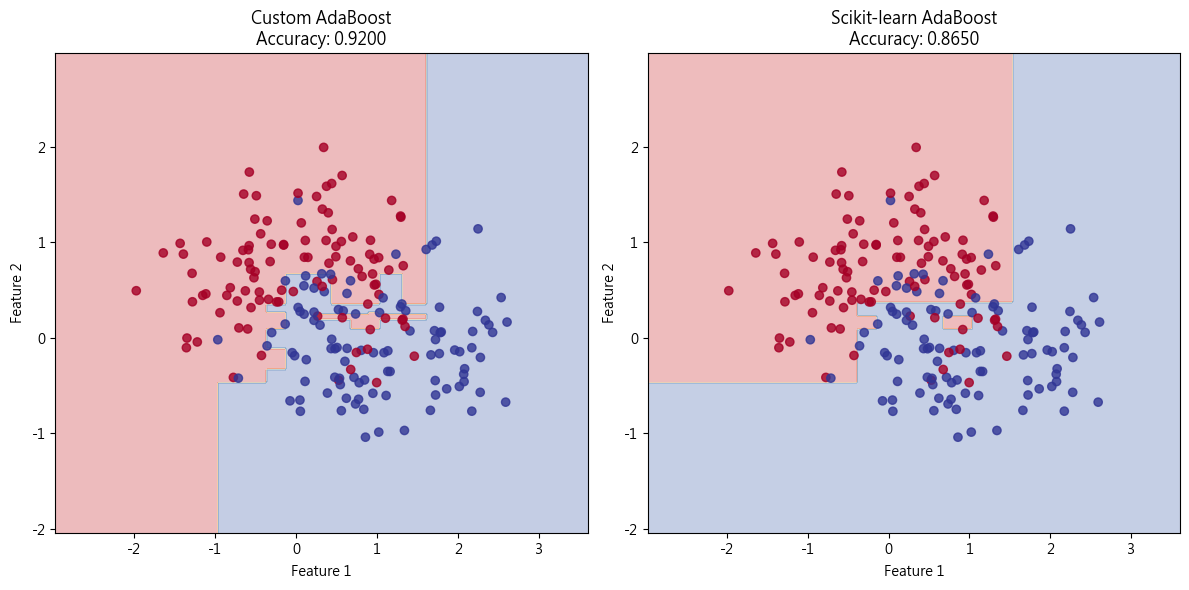


模型比較：
Custom AdaBoost Accuracy: 0.9200
Scikit-learn AdaBoost Accuracy: 0.8650


In [5]:
# 生成make_moons數據集
X, y = make_moons(n_samples=200, noise=0.4, random_state=42)
# 將標籤從0,1轉換為-1,1（用於自定義實現）
y_custom = 2 * y - 1

# 訓練自定義AdaBoost
n_estimators = 50
custom_clf = CustomAdaBoost(n_estimators=n_estimators)
custom_clf.fit(X, y_custom)
custom_accuracy = custom_clf.score(X, y_custom)

# 訓練Scikit-learn的AdaBoost
sklearn_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=n_estimators,
    random_state=42
)
sklearn_clf.fit(X, y)
sklearn_accuracy = sklearn_clf.score(X, y)

# 繪製比較圖
plt.figure(figsize=(12, 6))

# 自定義AdaBoost的決策邊界
plt.subplot(121)
plot_decision_boundary(custom_clf, X, y_custom, f'Custom AdaBoost\nAccuracy: {custom_accuracy:.4f}')

# Scikit-learn AdaBoost的決策邊界
plt.subplot(122)
plot_decision_boundary(sklearn_clf, X, y, f'Scikit-learn AdaBoost\nAccuracy: {sklearn_accuracy:.4f}')

plt.tight_layout()
plt.show()

# 打印詳細比較
print("\n模型比較：")
print(f"Custom AdaBoost Accuracy: {custom_accuracy:.4f}")
print(f"Scikit-learn AdaBoost Accuracy: {sklearn_accuracy:.4f}")